In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
train_data=pd.read_csv("sample_data/california_housing_train.csv")
test_data = pd.read_csv("sample_data/california_housing_test.csv")

In [3]:
print("Trian shape:", train_data.shape)
print("test shape:", test_data.shape)

Trian shape: (17000, 9)
test shape: (3000, 9)


In [4]:
numeric_train = train_data.select_dtypes(include="number")
print("Trian stats")
print(numeric_train.describe)
print("mean ", np.mean(train_data["median_house_value"]))
print("median ", np.median(train_data["median_house_value"]))
print("std ", np.std(train_data["median_house_value"]))

Trian stats
<bound method NDFrame.describe of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -114.31     34.19                15.0       5612.0          1283.0   
1        -114.47     34.40                19.0       7650.0          1901.0   
2        -114.56     33.69                17.0        720.0           174.0   
3        -114.57     33.64                14.0       1501.0           337.0   
4        -114.57     33.57                20.0       1454.0           326.0   
...          ...       ...                 ...          ...             ...   
16995    -124.26     40.58                52.0       2217.0           394.0   
16996    -124.27     40.69                36.0       2349.0           528.0   
16997    -124.30     41.84                17.0       2677.0           531.0   
16998    -124.30     41.80                19.0       2672.0           552.0   
16999    -124.35     40.54                52.0       1820.0           300.0   

     

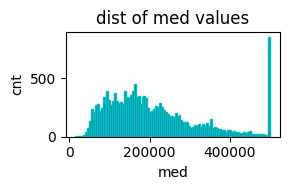

In [5]:
plt.figure(figsize=(3,2))
plt.hist(train_data["median_house_value"], bins=100, edgecolor="c")
plt.xlabel("med")
plt.ylabel("cnt")
plt.title("dist of med values")
plt.tight_layout()
plt.show()

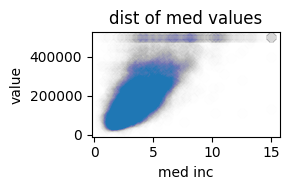

In [6]:
plt.figure(figsize=(3,2))
plt.scatter(train_data["median_income"], train_data["median_house_value"], alpha = .005, s = 50)
plt.xlabel("med inc")
plt.ylabel("value")
plt.title("dist of med values")
plt.tight_layout()
plt.show()

In [7]:
def add_features(df):
  df = df.copy()
  df["rooms_per_household"] = df["total_rooms"]/df["households"]
  df["bedrooms_per_room"] = df["total_bedrooms"]/df["total_rooms"]
  df["population_per_household"] = df["population"]/df["households"]
  return df.replace([np.inf, -np.inf], np.nan).dropna()
train_work = add_features(train_data)
test_work = add_features(test_data)

In [8]:
feature_cols = ["median_income", "housing_median_age", "latitude", "longitude", "rooms_per_household", "total_rooms", "households", "bedrooms_per_room", "total_bedrooms", "population_per_household", "population"]

In [9]:
x_train_full = train_work[feature_cols]
y_train_full = train_work["median_house_value"]
x_test = test_work[feature_cols]
y_test = test_work["median_house_value"]

In [10]:
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2)

In [11]:
models = {"LR": LinearRegression(), "R":Pipeline([("scaler", StandardScaler()),("model",Ridge(alpha=1.0))]), "RF": RandomForestRegressor(n_estimators=100, n_jobs=-1), "HGB":HistGradientBoostingRegressor()}

In [13]:
results = []
for name, model in models.items():
  model.fit(x_train,y_train)
  val_pred = model.predict(x_val)
  rmse = np.sqrt(mean_squared_error(y_val, val_pred))
  r2=r2_score(y_val, val_pred)
  results.append((name,rmse,r2))
  print(f"{name}:ValRMSE={rmse:.2f},VALR@={r2:.4f}")

LR:ValRMSE=104382.88,VALR@=0.2017
R:ValRMSE=104425.46,VALR@=0.2010
RF:ValRMSE=48968.33,VALR@=0.8243
HGB:ValRMSE=44882.48,VALR@=0.8524


In [18]:
results_df = pd.DataFrame(results, columns = ["model", "val_rmse", "val_r2"]).sort_values("val_rmse")
print("\nValidation Comparision")
print(results_df)
best_name = results_df.iloc[0]["model"]
best_model = models[best_name]
best_model.fit(x_train_full, y_train_full)
test_pred = best_model.predict(x_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)
print("\n Best Model:", best_name)
print("test rmse", test_rmse)
print("testr2", test_r2)


Validation Comparision
  model       val_rmse    val_r2
3   HGB   44882.481460  0.852402
2    RF   48968.330829  0.824305
0    LR  104382.884030  0.201663
1     R  104425.462945  0.201011

 Best Model: HGB
test rmse 48151.5739004744
testr2 0.818745261009592


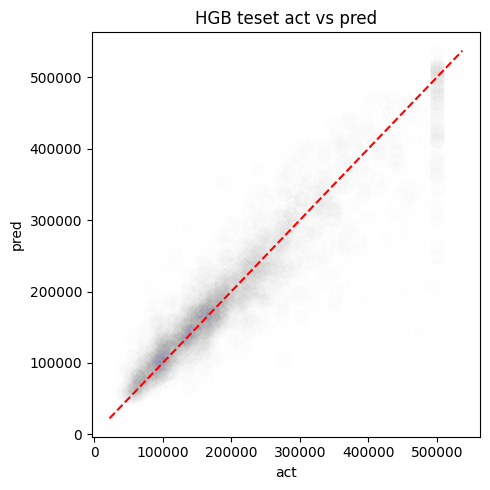

In [23]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, test_pred, alpha = 0.005, s = 100)
mn = min(y_test.min(), test_pred.min())
mx = max(y_test.max(), test_pred.max())
plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("act")
plt.ylabel("pred")
plt.title(f"{best_name} teset act vs pred")
plt.tight_layout()
plt.show()

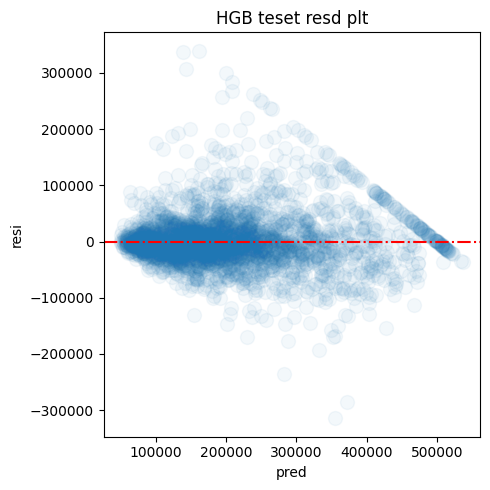

In [25]:
residuals = y_test-test_pred
plt.figure(figsize=(5,5))
plt.scatter(test_pred, residuals, alpha = 0.05, s = 100)
plt.axhline(0, color="red", linestyle="-.")
plt.xlabel("pred")
plt.ylabel("resi")
plt.title(f"{best_name} teset resd plt")
plt.tight_layout()
plt.show()